# Módulo 1: Simulación de Siniestros

## Modelo Colectivo de Riesgo

La pérdida agregada del portafolio se modela como:

$$S = \sum_{j=1}^{N} Y_j$$

donde:
- $N \sim \text{Poisson}(\lambda)$ es la frecuencia de siniestros
- $Y_j$ es la severidad del siniestro $j$, con distribución de cola pesada
- $S$ es la pérdida agregada total del periodo

In [43]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.simulation import simulate_aggregate_losses

# Estilo de gráficas
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## Simulación con distribución Pareto

La distribución Pareto tiene cola muy pesada, ideal para modelar siniestros catastróficos.

$$F(y) = 1 - \left(\frac{x_m}{y}\right)^\alpha, \quad y \geq x_m$$

Con $\alpha = 1.5$ y $x_m = 1000$, la varianza es infinita.

In [44]:
# Simulación con severidad Pareto
S_pareto = simulate_aggregate_losses(
    n_simulations=100000,
    lam=50.0,
    severity="pareto",
    pareto_alpha=1.5,
    pareto_xm=1_000.0,
    random_seed=42
)

print(f"Escenarios simulados : {len(S_pareto):,}")
print(f"Pérdida media        : {S_pareto.mean():,.2f}")
print(f"Desviación estándar  : {S_pareto.std():,.2f}")
print(f"Pérdida mínima       : {S_pareto.min():,.2f}")
print(f"Pérdida máxima       : {S_pareto.max():,.2f}")

Escenarios simulados : 100,000
Pérdida media        : 149,069.14
Desviación estándar  : 204,664.09
Pérdida mínima       : 44,373.99
Pérdida máxima       : 40,184,892.30


## Distribución de la Pérdida Agregada — Pareto

Visualizamos la distribución empírica de $S$ para identificar:
- La concentración de pérdidas típicas
- La cola derecha con escenarios catastróficos

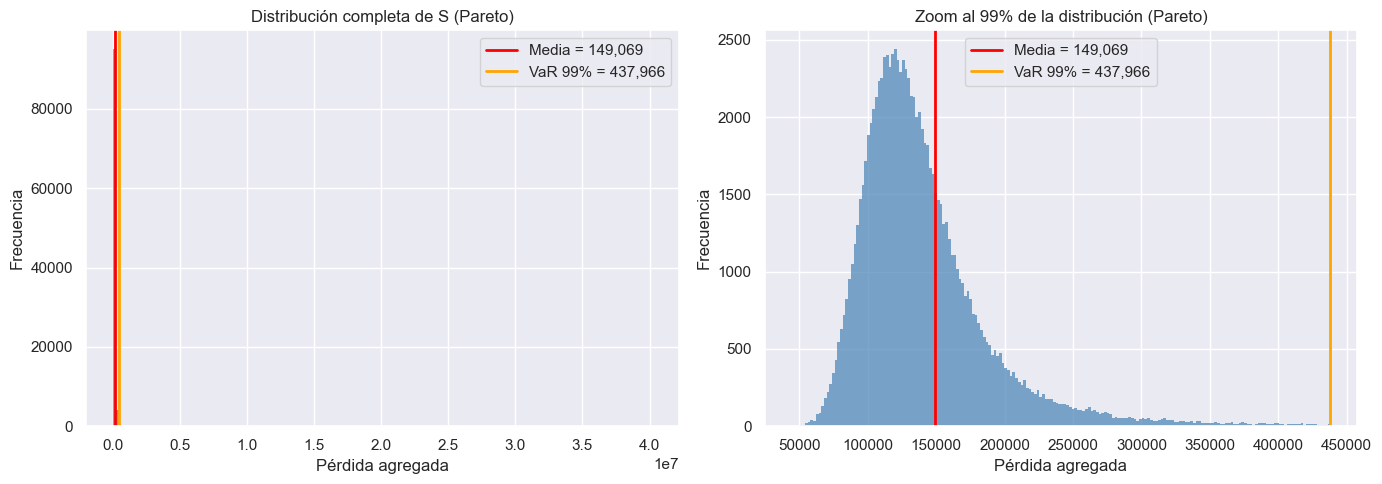

VaR 99%  : 437,966.07


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: histograma completo
axes[0].hist(S_pareto, bins=200, color="steelblue", edgecolor="none", alpha=0.7)
axes[0].axvline(S_pareto.mean(), color="red", linewidth=2, label=f"Media = {S_pareto.mean():,.0f}")
axes[0].axvline(np.percentile(S_pareto, 99), color="orange", linewidth=2, label=f"VaR 99% = {np.percentile(S_pareto, 99):,.0f}")
axes[0].set_title("Distribución completa de S (Pareto)")
axes[0].set_xlabel("Pérdida agregada")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

#Gráfica 2: zoom al 99% (sin cola extrema) 
p99 = np.percentile(S_pareto, 99)
S_zoom = S_pareto[S_pareto <= p99]

axes[1].hist(S_zoom, bins=200, color="steelblue", edgecolor="none", alpha=0.7)
axes[1].axvline(S_pareto.mean(), color="red", linewidth=2, label=f"Media = {S_pareto.mean():,.0f}")
axes[1].axvline(p99, color="orange", linewidth=2, label=f"VaR 99% = {p99:,.0f}")
axes[1].set_title("Zoom al 99% de la distribución (Pareto)")
axes[1].set_xlabel("Pérdida agregada")
axes[1].set_ylabel("Frecuencia")
axes[1].legend()

plt.tight_layout()
plt.savefig("../figures/01_pareto_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"VaR 99%  : {np.percentile(S_pareto, 99):,.2f}")


## Simulación con distribución Lognormal

Si $Y \sim \text{Lognormal}(\mu, \sigma)$ entonces $\ln(Y) \sim \mathcal{N}(\mu, \sigma^2)$.

Con $\mu = 8$ y $\sigma = 1.5$, la media de cada siniestro es:

$$\mathbb{E}[Y] = e^{\mu + \sigma^2/2} = e^{9.125} \approx 9{,}198$$

In [46]:
# Simulación con severidad Lognormal
S_lognormal = simulate_aggregate_losses(
    n_simulations=100_000,
    lam=50.0,
    severity="lognormal",
    lognormal_mu=8.0,
    lognormal_sigma=1.5,
    random_seed=42
)

print(f"Escenarios simulados : {len(S_lognormal):,}")
print(f"Pérdida media        : {S_lognormal.mean():,.2f}")
print(f"Desviación estándar  : {S_lognormal.std():,.2f}")
print(f"Pérdida mínima       : {S_lognormal.min():,.2f}")
print(f"Pérdida máxima       : {S_lognormal.max():,.2f}")
print(f"VaR 99%              : {np.percentile(S_lognormal, 99):,.2f}")

Escenarios simulados : 100,000
Pérdida media        : 458,928.03
Desviación estándar  : 199,988.71
Pérdida mínima       : 91,406.51
Pérdida máxima       : 9,247,430.96
VaR 99%              : 1,133,552.16


## Comparación Pareto vs Lognormal

Comparamos las distribuciones empíricas de $S$ para ambas severidades.
Usamos escala logarítmica en el eje X para apreciar la cola.

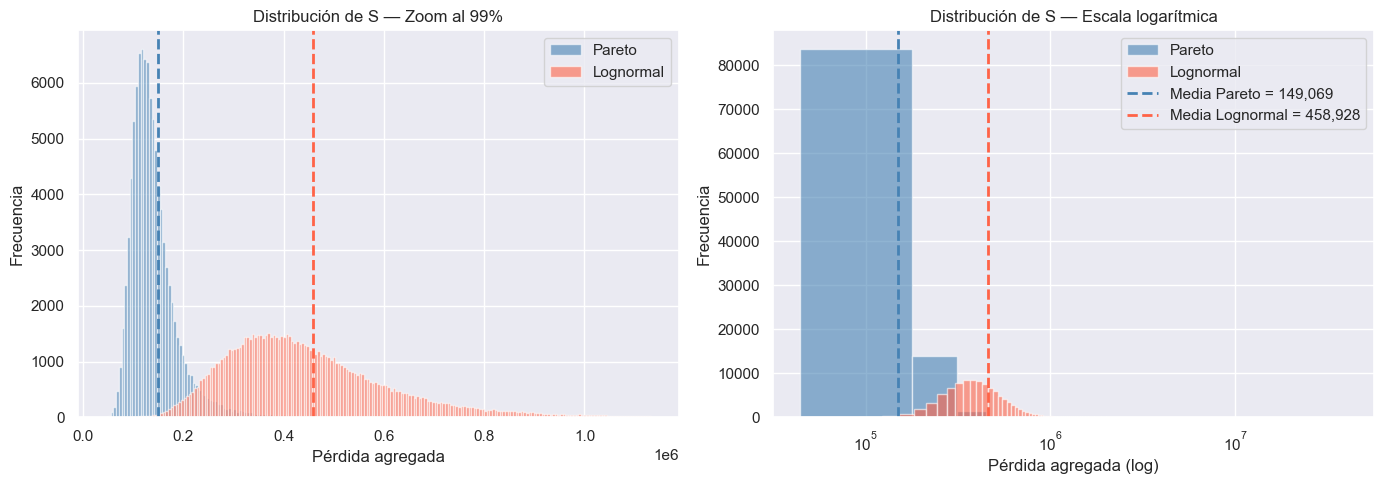

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#  Gráfica 1: escala normal, zoom al 99% 
p99_pareto = np.percentile(S_pareto, 99)
p99_lognormal = np.percentile(S_lognormal, 99)
x_max = max(p99_pareto, p99_lognormal)

axes[0].hist(S_pareto[S_pareto <= x_max], bins=200, alpha=0.6, 
             color="steelblue", label="Pareto")
axes[0].hist(S_lognormal[S_lognormal <= x_max], bins=200, alpha=0.6, 
             color="tomato", label="Lognormal")
axes[0].axvline(S_pareto.mean(), color="steelblue", linewidth=2, linestyle="--")
axes[0].axvline(S_lognormal.mean(), color="tomato", linewidth=2, linestyle="--")
axes[0].set_title("Distribución de S — Zoom al 99%")
axes[0].set_xlabel("Pérdida agregada")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

#  Gráfica 2: escala logarítmica en X 
axes[1].hist(S_pareto, bins=300, alpha=0.6, color="steelblue", label="Pareto")
axes[1].hist(S_lognormal, bins=300, alpha=0.6, color="tomato", label="Lognormal")
axes[1].set_xscale("log")
axes[1].axvline(S_pareto.mean(), color="steelblue", linewidth=2, 
                linestyle="--", label=f"Media Pareto = {S_pareto.mean():,.0f}")
axes[1].axvline(S_lognormal.mean(), color="tomato", linewidth=2, 
                linestyle="--", label=f"Media Lognormal = {S_lognormal.mean():,.0f}")
axes[1].set_title("Distribución de S — Escala logarítmica")
axes[1].set_xlabel("Pérdida agregada (log)")
axes[1].set_ylabel("Frecuencia")
axes[1].legend()

plt.tight_layout()
plt.savefig("../figures/02_pareto_vs_lognormal.png", dpi=150, bbox_inches="tight")
plt.show()

## Guardado de datos simulados

Guardamos ambas simulaciones en formato parquet para usarlas
en los módulos siguientes sin necesidad de re-simular.

In [49]:
# Guardar simulaciones en data/
df = pd.DataFrame({
    "S_pareto": S_pareto,
    "S_lognormal": S_lognormal
})

df.to_csv("../data/simulated_losses.csv", index=False)

print(f"Datos guardados en data/simulated_losses.csv")
print(f"Shape: {df.shape}")
print(f"\nResumen:")
print(df.describe().map(lambda x: f"{x:,.2f}"))

Datos guardados en data/simulated_losses.csv
Shape: (100000, 2)

Resumen:
            S_pareto   S_lognormal
count     100,000.00    100,000.00
mean      149,069.14    458,928.03
std       204,665.11    199,989.71
min        44,373.99     91,406.51
25%       110,120.80    331,599.86
50%       131,059.07    421,463.89
75%       159,955.44    539,051.86
max    40,184,892.30  9,247,430.96
